In [20]:
import pandas as pd
from datetime import date
import matplotlib.pyplot as plt


df_players = pd.read_csv("PicMoney-Base_Cadastral_de_Players-10_000 linhas (1).csv", sep=";")
base_transacoes = pd.read_csv("PicMoney-Base_de_Transa__es_-_Cupons_Capturados-100000 linhas (1).csv", sep=";")
base_simulacao = pd.read_csv("PicMoney-Base_Simulada_-_Pedestres_Av__Paulista-100000 linhas (1).csv", sep=";")
base_lojas = pd.read_csv("PicMoney-Massa_de_Teste_com_Lojas_e_Valores-10000 linhas (1).csv", sep=";")

In [11]:
df_players.head()

,celular,data_nascimento,idade,sexo,cidade_residencial,bairro_residencial,cidade_trabalho,bairro_trabalho,cidade_escola,bairro_escola,categoria_frequentada
0,(11) 91409-5506,12/10/1969,55,Masculino,São Paulo,Sé,NaN,NaN,NaN,NaN,Farmácias e Drogarias
1,(11) 91520-1488,19/02/1981,44,Masculino,São Paulo,Ipiranga,NaN,NaN,NaN,NaN,Postos de Combustível e Serviços Automotivos
2,(11) 98359-5557,10/09/1979,45,Masculino,São Paulo,Santana,NaN,NaN,NaN,NaN,Restaurantes e Gastronomia
3,(11) 96514-2674,05/03/1957,68,Masculino,São Paulo,Penha,NaN,NaN,NaN,NaN,Farmácias e Drogarias
4,(11) 99785-3045,30/10/1969,55,Feminino,São Paulo,Tatuapé,NaN,NaN,NaN,NaN,Clínicas de Saúde e Bem-estar


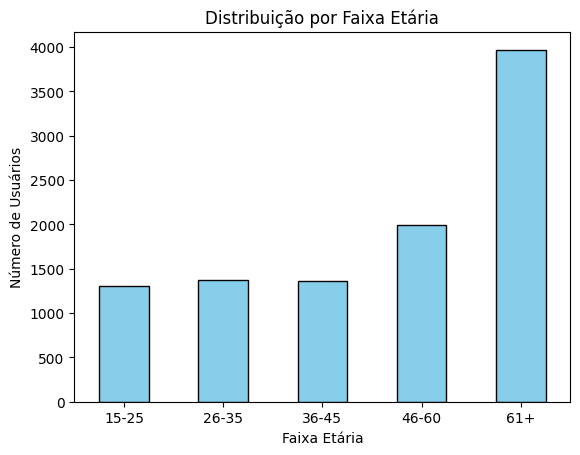

In [34]:

df_players["data_nascimento"] = pd.to_datetime(df_players["data_nascimento"], format="%d/%m/%Y", errors="coerce")

df_players["idade"] = (hoje.year - df_players["data_nascimento"].dt.year)
hoje = pd.to_datetime(date.today())

df_players["idade"] = (
    hoje.year - df_players["data_nascimento"].dt.year
    - ((hoje.month < df_players["data_nascimento"].dt.month) |
       ((hoje.month == df_players["data_nascimento"].dt.month) &
        (hoje.day < df_players["data_nascimento"].dt.day)))
)

media_idade = df_players["idade"].mean()
maior_idade = df_players["idade"].max()
menor_idade = df_players["idade"].min()

bins = [15, 25, 35, 45, 60, 100]  
labels = ["15-25", "26-35", "36-45", "46-60", "61+"]

df_players["faixa_etaria"] = pd.cut(df_players["idade"], bins=bins, labels=labels, right=True)

faixa_counts = df_players["faixa_etaria"].value_counts().sort_index()

faixa_counts.plot(kind="bar", edgecolor="black", color="skyblue")
plt.title("Distribuição por Faixa Etária")
plt.xlabel("Faixa Etária")
plt.ylabel("Número de Usuários")
plt.xticks(rotation=0)
plt.show()
